In [15]:
import os
import shutil

In [16]:


# # Define the paths
# source_folder = '/home/bhcp0089/Desktop/AiMedicalChatbot_updated/eye/all_images/test'  # Replace with your source folder path
# destination_folder = '/home/bhcp0089/Desktop/AiMedicalChatbot_updated/data/Test/Healthy/'  # Replace with your destination folder path

# # Ensure destination folder exists
# os.makedirs(destination_folder, exist_ok=True)

# # Loop through all the images in the source folder
# for filename in os.listdir(source_folder):
#     # Construct the full file path
#     source_file = os.path.join(source_folder, filename)
    
#     # Check if it's a file (image file)
#     if os.path.isfile(source_file):
#         # Construct destination file path
#         destination_file = os.path.join(destination_folder, filename)
        
#         # Copy the file from source to destination
#         shutil.copy(source_file, destination_file)

# print(f"All images from {source_folder} have been copied to {destination_folder}.")


In [17]:
# import os
# import random
# import shutil

# def move_half_images(source_folder, destination_folder):
#     # Create destination folder if it doesn't exist
#     os.makedirs(destination_folder, exist_ok=True)

#     # Get a list of all image files in the source folder
#     image_files = [f for f in os.listdir(source_folder) if f.lower().endswith(('png', 'jpg', 'jpeg', 'bmp', 'tiff'))]

#     # Shuffle and select half of the images
#     random.shuffle(image_files)
#     num_to_move = len(image_files) // 3
#     images_to_move = image_files[:num_to_move]

#     # Move selected images to the destination folder
#     for img in images_to_move:
#         src_path = os.path.join(source_folder, img)
#         dest_path = os.path.join(destination_folder, img)
#         shutil.move(src_path, dest_path)

#     print(f"Moved {num_to_move} images from {source_folder} to {destination_folder}")

# # Example usage
# source_folder = "/home/bhcp0089/Desktop/AiMedicalChatbot_updated/archive/preprocessed/M"
# destination_folder = "/home/bhcp0089/Desktop/AiMedicalChatbot_updated//data/eye_vs_non_eye/Test/miopia"
# move_half_images(source_folder, destination_folder)


In [18]:
import os

# Path to the dataset folder
dataset_folder = '/home/bhcp0089/Desktop/AiMedicalChatbot_updated/archive/preprocessed'  # Replace with your dataset folder path

# Loop through all subfolders (labels)
for label_folder in os.listdir(dataset_folder):
    label_folder_path = os.path.join(dataset_folder, label_folder)
    
    # Check if it's a directory (folder)
    if os.path.isdir(label_folder_path):
        # Count the number of image files in the folder (e.g., files ending with .jpg, .png)
        image_count = len([f for f in os.listdir(label_folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif'))])
        
        # Print the number of images in this folder
        print(f"Folder '{label_folder}' contains {image_count} images.")


Folder 'C' contains 1008 images.
Folder 'G' contains 1646 images.
Folder 'D' contains 3128 images.
Folder 'N' contains 2997 images.
Folder 'M' contains 329 images.
Folder 'A' contains 511 images.
Folder 'H' contains 420 images.


In [ ]:
import os
import shutil
import random

# Define the source and target directories
source_dir = '/home/bhcp0089/Desktop/AiMedicalChatbot_updated/archive/preprocessed'  # Replace with your source directory
target_dir = '/home/bhcp0089/Desktop/AiMedicalChatbot_updated/balanced/preprocessed'  # Replace with your destination directory

# Define the minimum and maximum image counts
min_images = 329  # The minimum number of images you want in each class (based on 'Cold Sores')
max_images = 3128  # The maximum number of images (based on 'Scars')

# Loop through all the class folders
for label in os.listdir(source_dir):
    label_path = os.path.join(source_dir, label)
    
    # If the folder is not a directory, skip it
    if not os.path.isdir(label_path):
        continue
    
    # Get the list of images in the class folder
    image_files = [f for f in os.listdir(label_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif'))]
    
    # Create target directory for the class folder if it doesn't exist
    target_label_dir = os.path.join(target_dir, label)
    os.makedirs(target_label_dir, exist_ok=True)

    # Get the current number of images in the class
    current_image_count = len(image_files)

    # If there are fewer images than desired, duplicate images
    if current_image_count < max_images:
        print(f"Over-sampling: {label} has {current_image_count} images. Duplicating to {max_images} images.")

        # Calculate how many times we need to duplicate the images
        duplicates_needed = max_images - current_image_count

        # Duplicate images
        while duplicates_needed > 0:
            random_image = random.choice(image_files)
            source_image_path = os.path.join(label_path, random_image)
            target_image_path = os.path.join(target_label_dir, f"{random.randint(1, 100000)}_{random_image}")
            
            shutil.copy2(source_image_path, target_image_path)
            duplicates_needed -= 1
    else:
        # If the current class has more than the desired number of images, just copy them
        print(f"Copying {label} images as they are sufficient.")
        for image in image_files:
            source_image_path = os.path.join(label_path, image)
            target_image_path = os.path.join(target_label_dir, image)
            shutil.copy2(source_image_path, target_image_path)

print("Over-sampling completed. Dataset is balanced.")


Over-sampling: C has 1008 images. Duplicating to 3128 images.
Over-sampling: G has 1646 images. Duplicating to 3128 images.
Copying D images as they are sufficient.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import accuracy_score, classification_report
import os
from tqdm import tqdm

In [ ]:
import os
import shutil
import random

def create_testing_folder(training_dir, testing_dir, split_ratio=0.2):
    # Ensure the testing directory exists
    if not os.path.exists(testing_dir):
        os.makedirs(testing_dir)

    # Iterate through each subfolder (label) in the training directory
    for class_folder in os.listdir(training_dir):
        class_path = os.path.join(training_dir, class_folder)
        
        if os.path.isdir(class_path):  # Only consider directories (subfolders)
            # Create the same folder structure in the testing directory
            test_class_path = os.path.join(testing_dir, class_folder)
            if not os.path.exists(test_class_path):
                os.makedirs(test_class_path)

            # Get all the image files in the class folder
            all_images = [img for img in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, img))]

            # Calculate the number of images to move to testing based on the split ratio
            num_images_to_move = int(len(all_images) * split_ratio)

            # Randomly select images to move to the testing folder
            images_to_move = random.sample(all_images, num_images_to_move)

            # Move the selected images to the testing folder
            for image in images_to_move:
                src_image = os.path.join(class_path, image)
                dest_image = os.path.join(test_class_path, image)

                shutil.move(src_image, dest_image)
                print(f"Moved {image} from {class_folder} to testing folder.")

    print("Testing folder creation complete.")

# Define your directories
training_dir = '/home/bhcp0089/Desktop/AiMedicalChatbot_updated/balanced/preprocessed'  # Path to your training dataset
testing_dir = '/home/bhcp0089/Desktop/AiMedicalChatbot_updated/testingBalanced/preprocessed'  # Path where you want to create the testing folder

# Run the function to create the testing folder
create_testing_folder(training_dir, testing_dir, split_ratio=0.2)  # 20% for testing


Moved 69086_2136_left.jpg from C to testing folder.
Moved 60031_2176_right.jpg from C to testing folder.
Moved 71718__316_2112344.jpg from C to testing folder.
Moved 47415__218_687151.jpg from C to testing folder.
Moved 31394__241_7236668.jpg from C to testing folder.
Moved 10176_2226_left.jpg from C to testing folder.
Moved 81492__343_2631213.jpg from C to testing folder.
Moved 48087__196_4818116.jpg from C to testing folder.
Moved 89348__7_2330751.jpg from C to testing folder.
Moved 58114__334_6427863.jpg from C to testing folder.
Moved 57676__321_2144914.jpg from C to testing folder.
Moved 19642__158_2964657.jpg from C to testing folder.
Moved 2924__337_6800255.jpg from C to testing folder.
Moved 45827_2138_right.jpg from C to testing folder.
Moved 14847__293_1732996.jpg from C to testing folder.
Moved 18140__329_4545620.jpg from C to testing folder.
Moved 42278_cataract_052.png from C to testing folder.
Moved 27865_2100_right.jpg from C to testing folder.
Moved 88680__328_3269333.j

In [14]:
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split, Subset
from sklearn.model_selection import KFold
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import Counter
from torch.optim import lr_scheduler


In [13]:
# Define dataset paths
data_dir_train = "/home/bhcp0089/Desktop/AiMedicalChatbot_updated/balanced/preprocessed"
data_dir_test = "/home/bhcp0089/Desktop/AiMedicalChatbot_updated/testingBalanced/preprocessed"

# Define transformations for InceptionV3
transform = transforms.Compose([
    transforms.Resize((299, 299)),  # InceptionV3 requires at least 299x299
    transforms.RandomHorizontalFlip(),  # Data augmentation
    transforms.RandomRotation(10),  # Small rotations for robustness
    transforms.ToTensor(),  
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Standard normalization
])

# Load the training dataset
full_train_dataset = datasets.ImageFolder(root=data_dir_train, transform=transform)

# Load the test dataset
test_dataset = datasets.ImageFolder(root=data_dir_test, transform=transform)

Starting preprocessing...
Class distribution:
Class A: 2561 samples
Class M: 2730 samples
Class G: 200 samples
Class D: 2503 samples
Class H: 2751 samples
Class C: 1528 samples
Class N: 2398 samples


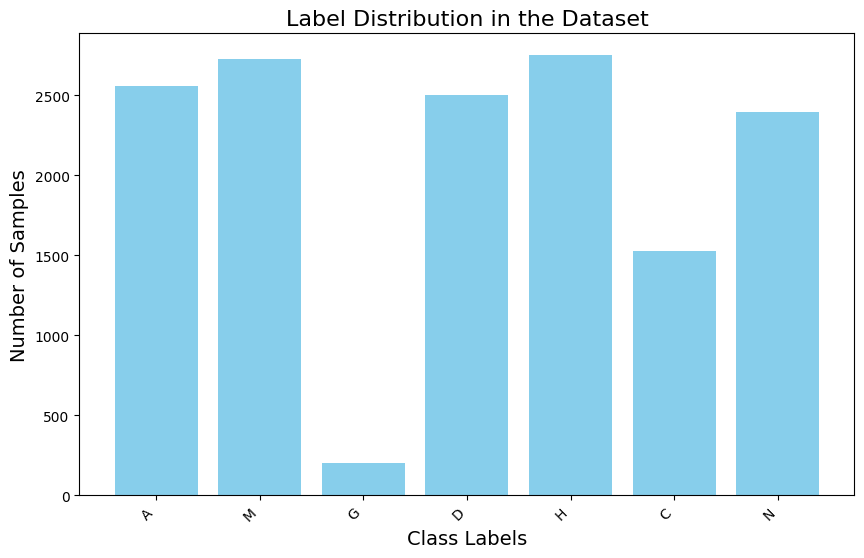

In [14]:
# Define DataLoader
batch_size = 32

# Preprocessing function to count label distribution
def preprocess_image_data(dataloader, class_names):
    print("Starting preprocessing...")

    label_counter = Counter()
    for _, labels in dataloader:  
        labels = labels.tolist()  # Convert to list (faster processing)
        label_counter.update(labels)

    print("Class distribution:")
    for label, count in label_counter.items():
        print(f"Class {class_names[label]}: {count} samples")

    return label_counter

# Optimized function to visualize label distribution
def visualize_label_distribution(label_counter, class_names):
    labels = [class_names[label] for label in label_counter.keys()]
    counts = list(label_counter.values())

    plt.figure(figsize=(10, 6))
    plt.bar(labels, counts, color='skyblue')
    plt.xlabel("Class Labels", fontsize=14)
    plt.ylabel("Number of Samples", fontsize=14)
    plt.title("Label Distribution in the Dataset", fontsize=16)
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.show()

# Visualize the label distribution in the training dataset
train_loader = DataLoader(full_train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
train_label_counter = preprocess_image_data(train_loader, full_train_dataset.classes)
visualize_label_distribution(train_label_counter, full_train_dataset.classes)


In [15]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [16]:
# Function to train the model for each fold
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10):
    best_acc = 0.0  # Track best validation accuracy

    # Training and evaluation
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # Training phase
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)

            # Handle auxiliary outputs for InceptionV3
            if isinstance(outputs, tuple):
                outputs = outputs[0]  

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)

        train_acc = correct_train / total_train
        epoch_loss = running_loss / total_train
        print(f"Train Loss: {epoch_loss:.4f}, Train Acc: {train_acc:.4f}")

        # Validation phase
        model.eval()
        correct_val = 0
        total_val = 0
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                if isinstance(outputs, tuple):
                    outputs = outputs[0]

                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                
                _, preds = torch.max(outputs, 1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

        val_acc = correct_val / total_val
        val_loss /= total_val

        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc

        scheduler.step()

    return best_acc


In [ ]:
import torch
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim.lr_scheduler as lr_scheduler
import matplotlib.pyplot as plt

# Define dataset paths
data_dir_train = "/home/bhcp0089/Desktop/AiMedicalChatbot_updated/archive/preprocessed"
data_dir_test = "/home/bhcp0089/Desktop/AiMedicalChatbot_updated/data/eye_vs_non_eye/Test"

# Define transformations for InceptionV3
transform = transforms.Compose([
    transforms.Resize((299, 299)),  # InceptionV3 requires at least 299x299
    transforms.RandomHorizontalFlip(),  # Data augmentation
    transforms.RandomRotation(10),  # Small rotations for robustness
    transforms.ToTensor(),  
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Standard normalization
])

# Load the full training dataset
full_train_dataset = datasets.ImageFolder(root=data_dir_train, transform=transform)

# Split train_data into train (90%) and validation (10%)
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Load the test dataset
test_dataset = datasets.ImageFolder(root=data_dir_test, transform=transform)

# Define DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load Pretrained InceptionV3 Model
model = models.inception_v3(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(full_train_dataset.classes))  # Adjust output layer for our dataset
model = model.to(device)

# Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)  # Lower LR for fine-tuning
scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)  # LR decay

# Training Function
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10):
    best_acc = 0.0  # Track best validation accuracy

    # Lists to store loss and accuracy
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # Training phase
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)

            # Handle auxiliary outputs for InceptionV3
            if isinstance(outputs, tuple):
                outputs = outputs[0]  

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)

        train_acc = correct_train / total_train
        epoch_loss = running_loss / total_train

        train_losses.append(epoch_loss)
        train_accuracies.append(train_acc)

        print(f"Train Loss: {epoch_loss:.4f}, Train Acc: {train_acc:.4f}")

        # Validation phase
        model.eval()
        correct_val = 0
        total_val = 0
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                if isinstance(outputs, tuple):
                    outputs = outputs[0]

                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                
                _, preds = torch.max(outputs, 1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

        val_acc = correct_val / total_val
        val_loss /= total_val

        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')  # Save the best model

        # Adjust learning rate
        scheduler.step()

    print(f"\n🎯 Best Validation Accuracy: {best_acc:.4f}")

    return train_losses, val_losses, train_accuracies, val_accuracies


# Train the model
train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10
)

# Save the model after training
torch.save(model.state_dict(), 'final_model.pth')  # Save the final model

# Testing the model
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    test_loss = 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            if isinstance(outputs, tuple):
                outputs = outputs[0]

            loss = criterion(outputs, labels)
            test_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    test_acc = correct / total
    test_loss /= total
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

    return test_loss, test_acc


# Load the saved model (in case you want to test later)
model = models.inception_v3(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(full_train_dataset.classes))  # Adjust output layer for our dataset
model.load_state_dict(torch.load('best_model.pth'))  # Load the best model saved
model = model.to(device)

# Test the model on the test dataset
test_loss, test_acc = test_model(model, test_loader)



Using device: cpu


/home/bhcp0089/Desktop/AiMedicalChatbot_updated/myenv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/bhcp0089/Desktop/AiMedicalChatbot_updated/myenv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Epoch 1/10
Train Loss: 0.7315, Train Acc: 0.7297
Val Loss: 0.5559, Val Acc: 0.7839

Epoch 2/10


In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# Load the class names
class_names = full_train_dataset.classes

# Define the same transformations used during training
transform = transforms.Compose([
    transforms.Resize((299, 299)),  # Resize to 299x299 for InceptionV3
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Standard normalization
])

# Function to classify a single image
def classify_image(image_path, model):
    # Load the image
    image = Image.open(image_path).convert('RGB')

    # Preprocess the image
    image = transform(image).unsqueeze(0)  # Add batch dimension (1, C, H, W)

    # Move the image to the same device as the model (GPU/CPU)
    image = image.to(device)

    # Set the model to evaluation mode
    model.eval()

    # Predict the class
    with torch.no_grad():
        outputs = model(image)

        # InceptionV3 returns a tuple with auxiliary output, so we only need the main output
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        # Get the predicted class
        _, predicted_class = torch.max(outputs, 1)

    # Get the class name
    predicted_label = class_names[predicted_class.item()]
    return predicted_label

# Test the function with an image
image_path = "/home/bhcp0089/Desktop/AiMedicalChatbot_updated/myipia-test.png"  # Replace with the path to your image
predicted_label = classify_image(image_path, model)

# Print the result
print(f"The predicted class for the image is: {predicted_label}")



The predicted class for the image is: Eczema


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np

# ✅ 1. Define dataset paths
data_dir_train = "/kaggle/working/skinD"
data_dir_test = "/kaggle/working/Test"

# ✅ 2. Define transformations for EfficientNet (for better generalization)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # EfficientNet works with 224x224 images
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # Data augmentation
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # More diversity
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  
])

# ✅ 3. Load datasets
full_train_dataset = datasets.ImageFolder(root=data_dir_train, transform=transform)
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])
test_dataset = datasets.ImageFolder(root=data_dir_test, transform=transform)

# ✅ 4. DataLoader
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

# ✅ 5. Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ✅ 6. Load Pretrained EfficientNet (Best for Generalization)
model = models.efficientnet_b0(pretrained=True)
num_ftrs = model.classifier[1].in_features  # Get input size of last layer
model.classifier = nn.Sequential(
    nn.Dropout(0.4),  # Regularization
    nn.Linear(num_ftrs, len(full_train_dataset.classes))  # Replace last layer
)
model = model.to(device)

# ✅ 7. Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)  # L2 Regularization
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, verbose=True)  # Reduce LR on plateau

# ✅ 8. Early Stopping Function
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_acc = 0.0

    def check(self, val_acc):
        if val_acc > self.best_acc:
            self.best_acc = val_acc
            self.counter = 0
            return False  # Continue training
        else:
            self.counter += 1
            return self.counter >= self.patience  # Stop training if no improvement

early_stopping = EarlyStopping(patience=5)

# ✅ 9. Training Function
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=30):
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # 🔥 Training phase
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct_train += (outputs.argmax(1) == labels).sum().item()
            total_train += labels.size(0)

        train_acc = correct_train / total_train
        train_loss = running_loss / total_train
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")

        # 🔥 Validation phase
        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                correct_val += (outputs.argmax(1) == labels).sum().item()
                total_val += labels.size(0)

        val_acc = correct_val / total_val
        val_loss /= total_val
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), 'woww.pth')

        # Reduce LR if needed
        scheduler.step(val_loss)

        # Stop training if validation accuracy does not improve
        if early_stopping.check(val_acc):
            print("Early stopping triggered!")
            break

    print(f"\n🎯 Best Validation Accuracy: {best_acc:.4f}")
    return best_acc

# ✅ 10. Train the model
best_val_acc = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=30)

# ✅ 11. Load best model for testing
model.load_state_dict(torch.load('woww.pth'))
model = model.to(device)

# ✅ 12. Test the model
def test_model(model, test_loader):
    model.eval()
    correct, total, test_loss = 0, 0, 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    test_acc = correct / total
    test_loss /= total
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
    return test_loss, test_acc

# ✅ 13. Evaluate on test data
test_loss, test_acc = test_model(model, test_loader)


Using device: cuda

Epoch 1/30
Train Loss: 1.7689, Train Acc: 0.4652
Val Loss: 1.1142, Val Acc: 0.6351

Epoch 2/30
Train Loss: 1.0225, Train Acc: 0.6611
Val Loss: 0.8440, Val Acc: 0.7098

Epoch 3/30
Train Loss: 0.8236, Train Acc: 0.7234
Val Loss: 0.7379, Val Acc: 0.7568

Epoch 4/30
Train Loss: 0.6805, Train Acc: 0.7641
Val Loss: 0.6722, Val Acc: 0.7703

Epoch 5/30
Train Loss: 0.5896, Train Acc: 0.7890
Val Loss: 0.6788, Val Acc: 0.7824

Epoch 6/30
Train Loss: 0.5109, Train Acc: 0.8164
Val Loss: 0.6137, Val Acc: 0.7945

Epoch 7/30
Train Loss: 0.4468, Train Acc: 0.8355
Val Loss: 0.6263, Val Acc: 0.7987

Epoch 8/30
Train Loss: 0.3793, Train Acc: 0.8623
Val Loss: 0.6410, Val Acc: 0.7923

Epoch 9/30
Train Loss: 0.3439, Train Acc: 0.8715
Val Loss: 0.6320, Val Acc: 0.7966

Epoch 10/30
Train Loss: 0.3136, Train Acc: 0.8802
Val Loss: 0.6327, Val Acc: 0.8058

Epoch 11/30
Train Loss: 0.2586, Train Acc: 0.9003
Val Loss: 0.6258, Val Acc: 0.8058

Epoch 12/30
Train Loss: 0.2425, Train Acc: 0.9079
Val 

<ipython-input-110-78380b6b767c>:138: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('woww.pth'))


Test Loss: 0.6960, Test Acc: 0.8017


In [ ]:
import shutil

# Zip the folders
shutil.make_archive("/kaggle/working/skinD", 'zip', "/kaggle/outputs/skinD")
shutil.make_archive("/kaggle/working/Test", 'zip', "/kaggle/outputs/Test")

print("Folders compressed successfully!")


Folders compressed successfully!


In [ ]:
def count_trainable_params(model):
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"🔍 Total Parameters: {total_params:,}")
    print(f"✅ Trainable Parameters: {trainable_params:,}")

# Call the function
count_trainable_params(model)

🔍 Total Parameters: 4,033,168
✅ Trainable Parameters: 4,033,168


In [ ]:
from PIL import Image

# ✅ Load class names from the dataset
class_names = full_train_dataset.classes  # Extract class names

# ✅ Function to test a single image
def predict_single_image(model, image_path, transform, class_names):
    model.eval()  # Set model to evaluation mode
    
    # 🔹 Load and preprocess the image
    image = Image.open(image_path).convert("RGB")  # Ensure RGB mode
    image = transform(image)  # Apply transformations
    image = image.unsqueeze(0)  # Add batch dimension (1, C, H, W)
    
    image = image.to(device)  # Move image to GPU (if available)
    
    # 🔹 Perform inference
    with torch.no_grad():
        outputs = model(image)
        predicted_class = torch.argmax(outputs, dim=1).item()  # Get class index
    
    # 🔹 Print result
    predicted_label = class_names[predicted_class]
    print(f"Predicted Class: {predicted_label}")

# ✅ Example Usage (Provide the path to the image you want to test)
image_path = "/kaggle/working/Test/Puffy Eyes/43.jpg"  # Change to your test image path
predict_single_image(model, image_path, transform, class_names)


Predicted Class: Puffy Eyes


In [ ]:
print(class_names)

['Acne', 'ChickenPox', 'Cold Sores', 'DarkSpots', 'Eczema', 'Healthy', 'Moles', 'Monkeypox', 'NailFungus', 'Psoriasis', 'Puffy Eyes', 'Rash', 'RingWorm', 'Scabies', 'Scars', 'SkinCancer', 'SunnDamage', 'Vitiligo', 'Warts', 'Wrinkles']


In [ ]:
import torch
from PIL import Image
import torch.nn.functional as F

# ✅ Load class names from the dataset
class_names = full_train_dataset.classes  # Extract class names

# ✅ Function to test a single image with confidence score
def predict_single_image(model, image_path, transform, class_names):
    model.eval()  # Set model to evaluation mode

    # 🔹 Load and preprocess the image
    image = Image.open(image_path).convert("RGB")  # Ensure RGB mode
    image = transform(image)  # Apply transformations
    image = image.unsqueeze(0).to(device)  # Add batch dimension & move to GPU (if available)

    # 🔹 Perform inference
    with torch.no_grad():
        outputs = model(image)  # Raw logits
        probabilities = F.softmax(outputs, dim=1)  # Convert logits to probabilities
        predicted_class_idx = torch.argmax(probabilities, dim=1).item()  # Get class index
        confidence = probabilities[0, predicted_class_idx].item()  # Get confidence score
    
    # 🔹 Print result
    predicted_label = class_names[predicted_class_idx]
    print(f"Predicted Class: {predicted_label} | Confidence: {confidence:.2%}")  # Show as percentage

# ✅ Example Usage (Provide the path to the image you want to test)
image_path = "/kaggle/working/Test/Warts/genital-warts-38.jpeg"  # Change to your test image path
predict_single_image(model, image_path, transform, class_names)


Predicted Class: Warts | Confidence: 99.96%


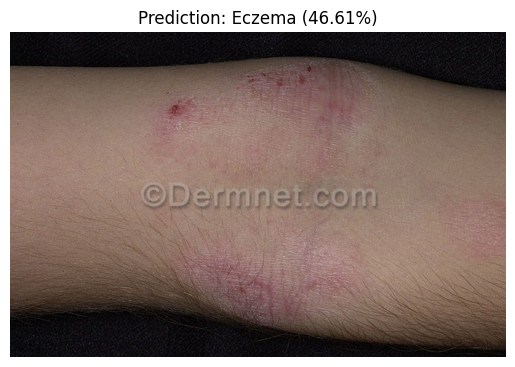

🔍 Top Predictions:
Eczema: 46.61%
Scabies: 31.97%
Rash: 18.43%


In [ ]:
import matplotlib.pyplot as plt
import torch
from PIL import Image

# ✅ Function to test a single image and display results
def predict_and_display(model, image_path, transform, class_names):
    model.eval()  # Set model to evaluation mode
    
    # 🔹 Load and preprocess the image
    image = Image.open(image_path).convert("RGB")  # Ensure RGB mode
    processed_image = transform(image)  # Apply transformations
    processed_image = processed_image.unsqueeze(0).to(device)  # Add batch dimension & move to GPU
    
    # 🔹 Perform inference
    with torch.no_grad():
        outputs = model(processed_image)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)  # Convert to probabilities
        top_probs, top_classes = torch.topk(probabilities, 3)  # Get top-3 predictions
    
    # 🔹 Convert results
    top_probs = top_probs.squeeze().cpu().numpy()  # Convert tensor to NumPy array
    top_classes = top_classes.squeeze().cpu().numpy()  # Convert tensor to NumPy array
    
    # 🔹 Display image
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Prediction: {class_names[top_classes[0]]} ({top_probs[0]*100:.2f}%)")
    plt.show()
    
    # 🔹 Print top 3 predictions
    print("🔍 Top Predictions:")
    for i in range(3):
        print(f"{class_names[top_classes[i]]}: {top_probs[i]*100:.2f}%")

# ✅ Example Usage
image_path = "/kaggle/working/Test/Scabies/05Atopic011011.jpg"  # Change to your test image path
predict_and_display(model, image_path, transform, class_names)



⚠️ Image is not clear. Possible classes:
Eczema: 46.61%
Scabies: 31.97%
Rash: 18.43%


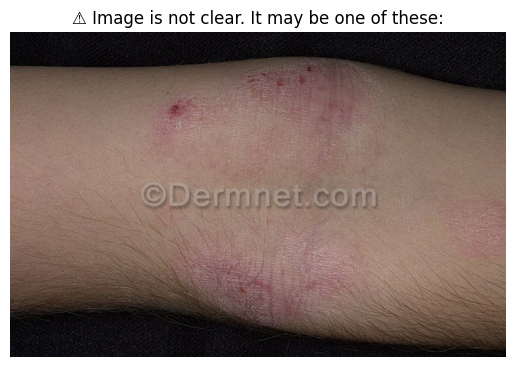

In [ ]:
import matplotlib.pyplot as plt
import torch
from PIL import Image

# ✅ Function to test a single image with a confidence threshold
def predict_with_threshold(model, image_path, transform, class_names, threshold=60):
    model.eval()  # Set model to evaluation mode
    
    # 🔹 Load and preprocess the image
    image = Image.open(image_path).convert("RGB")  # Ensure RGB mode
    processed_image = transform(image)  # Apply transformations
    processed_image = processed_image.unsqueeze(0).to(device)  # Add batch dimension & move to GPU
    
    # 🔹 Perform inference
    with torch.no_grad():
        outputs = model(processed_image)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)  # Convert to probabilities
        top_probs, top_classes = torch.topk(probabilities, 3)  # Get top-3 predictions
    
    # 🔹 Convert results
    top_probs = top_probs.squeeze().cpu().numpy() * 100  # Convert tensor to NumPy and scale to percentage
    top_classes = top_classes.squeeze().cpu().numpy()  # Convert tensor to NumPy array
    
    # 🔹 Display image
    plt.imshow(image)
    plt.axis("off")
    
    # 🔥 Check confidence level
    if top_probs[0] >= threshold:
        title = f"Prediction: {class_names[top_classes[0]]} ({top_probs[0]:.2f}%)"
    else:
        title = "⚠️ Image is not clear. It may be one of these:"
        print("\n⚠️ Image is not clear. Possible classes:")
        for i in range(3):
            print(f"{class_names[top_classes[i]]}: {top_probs[i]:.2f}%")
    
    plt.title(title)
    plt.show()

# ✅ Example Usage
image_path = "/kaggle/working/Test/Scabies/05Atopic011011.jpg"  # Change to your test image path
predict_with_threshold(model, image_path, transform, class_names, threshold=60)
